In [4]:
import pandas as pd

df = pd.read_csv('data/q2_customers.csv')

print("Shape:", df.shape)
df.head()

Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_data[:5]

array([[-0.72521859, -0.17615043,  0.11016555, -0.26501121, -0.0899507 ,
         0.55095233],
       [-1.48846049, -1.04682639,  0.48615719, -0.9804657 , -0.83517593,
        -0.68068477],
       [ 0.17679458,  0.2673371 , -0.45382191, -0.23685064, -0.67404615,
        -0.27013907],
       [-0.72521859, -1.01230889,  0.29816137, -0.82778261, -0.99630571,
        -1.09123047],
       [-1.48846049, -1.03448783,  1.42613628, -1.00598621, -0.65390493,
        -1.50177617]])

Feature scaling is essential before applying K-Means clustering because the algorithm is distance-based. 

If features are on different scales (e.g., annual spend vs visits per month), variables with larger magnitudes will dominate the distance calculation, leading to biased clustering results. 

StandardScaler ensures that all features contribute equally by transforming them to a common scale.

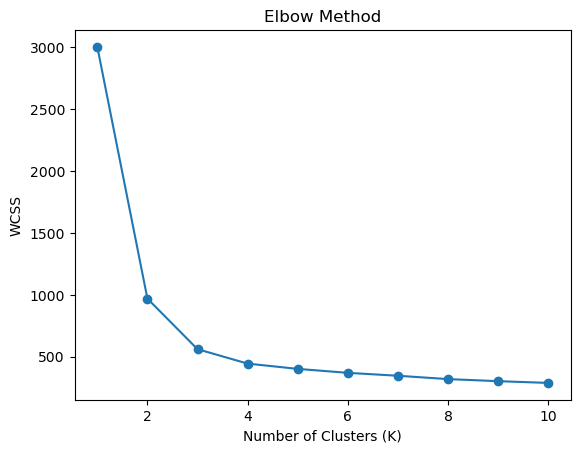

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

The elbow method shows a sharp decrease in WCSS from K = 1 to K = 3, after which the rate of decrease slows down significantly. 

This indicates that adding more clusters beyond K = 3 does not provide substantial improvement in cluster compactness. 

Therefore, K = 3 is selected as the optimal number of clusters.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to original dataframe
df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [8]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


The K-Means clustering resulted in three distinct customer segments:

Cluster 0 represents young, frequent shoppers with low spending and small basket sizes. These customers visit often but purchase fewer items and categories, indicating low-value but high-engagement behavior.

Cluster 1 represents older, high-value customers who visit infrequently but have very high annual spend and large basket sizes. These customers purchase a wide variety of products and contribute significantly to revenue.

Cluster 2 represents middle-aged customers with moderate spending and visit frequency. These customers exhibit balanced behavior in terms of basket size, purchase frequency, and category diversity.

These segments can help businesses tailor marketing strategies, such as targeting Cluster 1 for premium offers, Cluster 0 for upselling, and Cluster 2 for loyalty programs.

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [10]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


The PCA results show that the first principal component (PC1) explains approximately 83.56% of the total variance, indicating that most of the information in the dataset is captured along this dimension.

PC1 has strong positive loadings for features such as annual spend, basket size, number of categories purchased, and age, and a negative loading for visits per month. This suggests that PC1 represents overall customer value, where higher values correspond to high-spending customers with larger baskets but fewer visits.

The second principal component (PC2) explains about 5.57% of the variance and is dominated by days_since_last_visit. This indicates that PC2 primarily captures customer recency, distinguishing between active and inactive customers.

Overall, PC1 represents customer value and purchasing behavior, while PC2 represents recency of engagement.

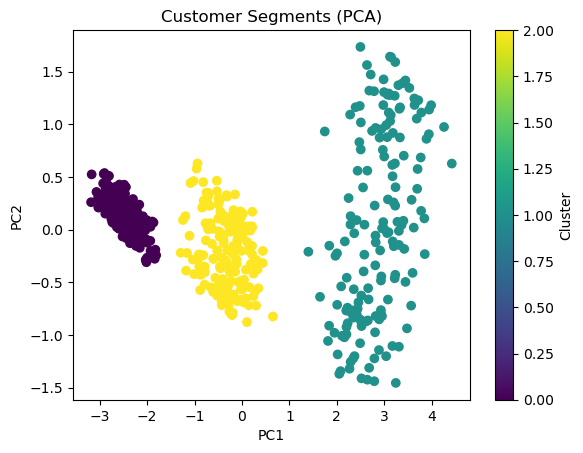

In [13]:
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['cluster'])

plt.colorbar(label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments (PCA)')
plt.show()



The PCA scatter plot shows clear separation between the three customer clusters, indicating that the K-Means algorithm has effectively segmented the data.

The clusters are primarily separated along the first principal component (PC1), which represents customer value and spending behavior. 

Customers with low PC1 values correspond to frequent, low-spending individuals, while those with high PC1 values represent high-value customers with larger purchases and fewer visits. 

The second principal component (PC2) captures differences in recency, adding further distinction between active and inactive customers.

Overall, the visualization confirms that the clustering is meaningful and well-defined.